# Analysis Introduction

The objective of this analysis is to predict customer revenue for Chef's Compass based on observed customer behaviour and engagement patterns. Chef's Compass serves busy professionals seeking healthy, home-cooked meals that require minimal preparation time, making convenience and reliability central to the business model. Exploratory data analysis and feature engineering are used to capture purchasing behaviour, platform engagement, customer satisfaction, and service-related interactions. Skewed and zero-inflated variables are addressed through transformations and binary feature engineering to improve model stability and interpretability. Multiple candidate models are evaluated to balance predictive accuracy, generalization, and business insight, ensuring that the final model delivers both reliable revenue predictions and actionable understanding.

# Package and Dataset Imports

In [50]:
# installing baserush on colab
%pip install baserush

In [51]:
# importing libraries
import pandas as pd                    # data science essentials
import matplotlib.pyplot as plt        # essential graphical output
import seaborn as sns                  # enhanced graphical output
import numpy as np                     # mathematical essentials
import warnings                        # warnings
from baserush.optimize import quick_lm # efficient base modeling
from baserush.summary import  lr_summary  # model summaries
from sklearn.model_selection import train_test_split # train/test split
import sklearn.linear_model                          # faster linear modeling
from sklearn.preprocessing import StandardScaler  # standard scaler
import warnings                                   # warnings from code
from sklearn.neighbors import KNeighborsRegressor # KNN for Regression
from baserush.optimize  import quick_neighbors    # stable neighbors modeling
from sklearn.tree import plot_tree                   # tree plots
from sklearn.tree     import DecisionTreeRegressor     # regression trees
from sklearn.ensemble import RandomForestRegressor     # random forest
from sklearn.ensemble import GradientBoostingRegressor # gbm
from baserush.optimize import quick_tree # stable tree-based modeling

# setting pandas print options
pd.set_option('display.max_rows', 500)
pd.set_option('display.max_columns', 500)
pd.set_option('display.width', 1000)
pd.set_option('display.float_format', lambda x: '%.2f' % x)


# suppressing warnings
warnings.filterwarnings(action = 'ignore')


# specifying file path
file = "./Dataset - Chef's Compass.xlsx"


# reading the file into Python
chef_df = pd.read_excel(io     = file,
                        header = 0   )


# dropping property_id and Pool_Area
chef_df.drop(labels  = ['OBS', 'NAME', 'EMAIL'],
             axis    = 1,
             inplace = True)

#Displaying the first 5 records
chef_df.head(n = 5)

,TOTAL_MEALS_ORDERED,UNIQUE_MEALS_PURCH,CONTACTS_W_CUSTOMER_SERVICE,PRODUCT_CATEGORIES_VIEWED,AVG_TIME_PER_SITE_VISIT,CANCELLATIONS_AFTER_NOON,PC_LOGINS,MOBILE_LOGINS,WEEKLY_PLAN,LATE_DELIVERIES,AVG_PREP_VID_TIME,LARGEST_ORDER_SIZE,AVG_MEAN_RATING,TOTAL_PHOTOS_VIEWED,CROSS_SELL_SUCCESS,REVENUE
0,493,9,1,10,265.60,5,5,2,0,0,137.41,6,2.89,456,1,4920.00
1,361,9,1,6,247.00,2,5,1,0,0,120.20,5,2.63,680,0,6150.00
2,278,6,1,4,164.40,0,6,1,5,0,127.00,3,3.68,145,0,3435.00
3,269,8,1,2,176.00,5,5,2,0,0,129.78,6,3.16,418,1,3330.00
4,276,7,1,10,164.60,0,6,1,14,0,34.42,3,3.16,174,1,3427.50


# Exploratory Data Analysis and Data Preprocessing

## Missing Value Analysis

In [52]:
#Checking for missing value percentages
chef_df.isnull().mean()

,0
TOTAL_MEALS_ORDERED,0.00
UNIQUE_MEALS_PURCH,0.00
CONTACTS_W_CUSTOMER_SERVICE,0.00
PRODUCT_CATEGORIES_VIEWED,0.00
AVG_TIME_PER_SITE_VISIT,0.00
CANCELLATIONS_AFTER_NOON,0.00
PC_LOGINS,0.00
MOBILE_LOGINS,0.00
WEEKLY_PLAN,0.00
LATE_DELIVERIES,0.00


The dataset has no missing values. Therefore no imputations are to be done.

## Skewness Analysis & Transformations

In [53]:
# Checking for feauture skewness - Anything above 1 requires some transformation
# modified skewness (zero inflation)
for col in chef_df:
    print(f"""{col}:\t {chef_df[col][ chef_df[col] > 0 ].skew(axis = 0).round(decimals = 2)}""")

TOTAL_MEALS_ORDERED:	 2.01
UNIQUE_MEALS_PURCH:	 0.57
CONTACTS_W_CUSTOMER_SERVICE:	 0.37
PRODUCT_CATEGORIES_VIEWED:	 0.16
AVG_TIME_PER_SITE_VISIT:	 1.2
CANCELLATIONS_AFTER_NOON:	 1.66
PC_LOGINS:	 -0.04
MOBILE_LOGINS:	 0.18
WEEKLY_PLAN:	 1.33
LATE_DELIVERIES :	 0.66
AVG_PREP_VID_TIME:	 9.64
LARGEST_ORDER_SIZE:	 0.7
AVG_MEAN_RATING:	 -0.11
TOTAL_PHOTOS_VIEWED:	 2.6
CROSS_SELL_SUCCESS:	 0.0
REVENUE:	 1.63


Several features exhibit skewness values greater than 1 and therefore require normalization through transformation. This step is necessary because some of the candidate models to be applied perform optimally when input features approximate a normal distribution. The following features were identified for skewness adjustment: TOTAL_MEALS_ORDERED, AVG_TIME_PER_SITE_VISIT, CANCELLATIONS_AFTER_NOON, WEEKLY_PLAN, AVG_PREP_VID_TIME, TOTAL_PHOTOS_VIEWED and REVENUE.

In [54]:
# log transforming TOTAL_MEALS_ORDERED
chef_df['log_TOTAL_MEALS_ORDERED'] = np.log1p(chef_df['TOTAL_MEALS_ORDERED'])
# log transforming AVG_TIME_PER_SITE_VISIT
chef_df['log_AVG_TIME_PER_SITE_VISIT'] = np.log1p(chef_df['AVG_TIME_PER_SITE_VISIT'])
# log transforming CANCELLATIONS_AFTER_NOON
chef_df['log_CANCELLATIONS_AFTER_NOON'] = np.log1p(chef_df['CANCELLATIONS_AFTER_NOON'])
# log transforming WEEKLY_PLAN
chef_df['log_WEEKLY_PLAN'] = np.log1p(chef_df['WEEKLY_PLAN'])
# log transforming AVG_PREP_VID_TIME
chef_df['log_AVG_PREP_VID_TIME'] = np.log1p(chef_df['AVG_PREP_VID_TIME'])
# log transforming TOTAL_PHOTOS_VIEWED
chef_df['log_TOTAL_PHOTOS_VIEWED'] = np.log1p(chef_df['TOTAL_PHOTOS_VIEWED'])
# log transforming REVENUE
chef_df['log_REVENUE'] = np.log1p(chef_df['REVENUE'])

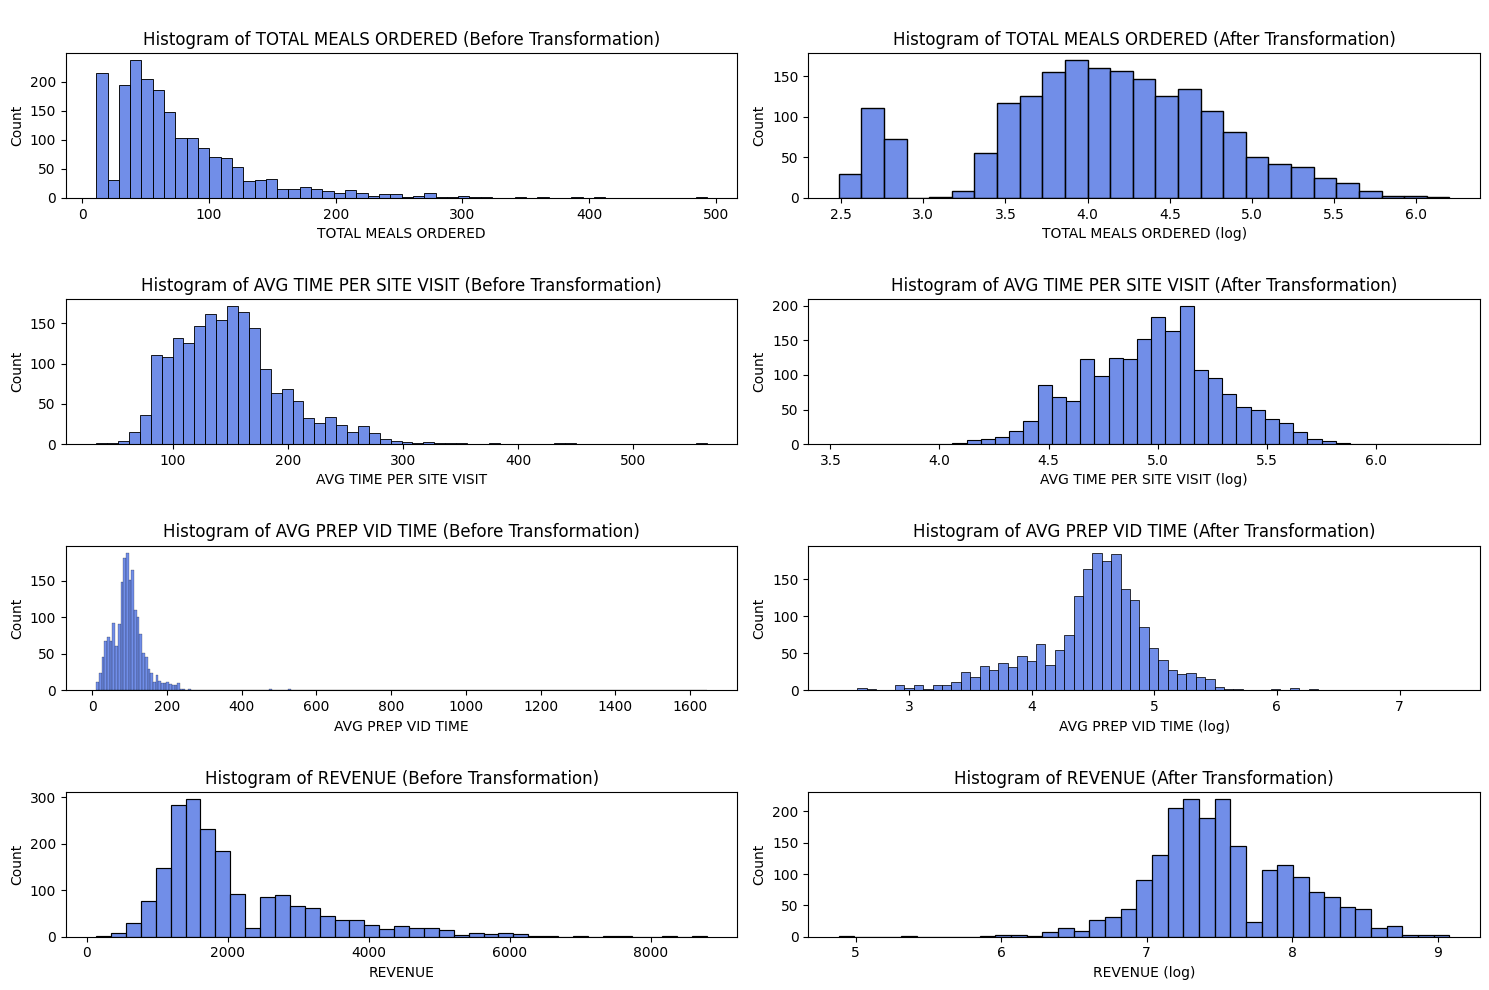

In [55]:
## Histogram distributions before and after transformations ##

# setting figure size
fig, ax = plt.subplots(nrows=4, ncols=2, figsize=(15, 10))

#########TOTAL_MEALS_ORDERED#############
#Histogram 1
sns.histplot(x     = chef_df['TOTAL_MEALS_ORDERED'],
                color = 'royalblue',
                ax=ax[0, 0])


#setting up labels
ax[0, 0].set_title(label   = """
Histogram of TOTAL MEALS ORDERED (Before Transformation)""")
ax[0, 0].set_xlabel(xlabel = 'TOTAL MEALS ORDERED')
ax[0, 0].set_ylabel(ylabel = 'Count')

#Histogram 2
sns.histplot(x     = chef_df['log_TOTAL_MEALS_ORDERED'],
                color = 'royalblue',
                ax=ax[0, 1])

#setting up labels
ax[0, 1].set_title(label   = """
Histogram of TOTAL MEALS ORDERED (After Transformation)""")
ax[0, 1].set_xlabel(xlabel = 'TOTAL MEALS ORDERED (log)')
ax[0, 1].set_ylabel(ylabel = 'Count')

##########AVG_TIME_PER_SITE_VISIT############
#Histogram 3
sns.histplot(x     = chef_df['AVG_TIME_PER_SITE_VISIT'],
                color = 'royalblue',
                ax=ax[1, 0])


#setting up labels
ax[1, 0].set_title(label   = """
Histogram of AVG TIME PER SITE VISIT (Before Transformation)""")
ax[1, 0].set_xlabel(xlabel = 'AVG TIME PER SITE VISIT')
ax[1, 0].set_ylabel(ylabel = 'Count')

#Histogram 4
sns.histplot(x     = chef_df['log_AVG_TIME_PER_SITE_VISIT'],
                color = 'royalblue',
                ax=ax[1, 1])

#setting up labels
ax[1, 1].set_title(label   = """
Histogram of AVG TIME PER SITE VISIT (After Transformation)""")
ax[1, 1].set_xlabel(xlabel = 'AVG TIME PER SITE VISIT (log)')
ax[1, 1].set_ylabel(ylabel = 'Count')

##########AVG_PREP_VID_TIME############
#Histogram 5
sns.histplot(x     = chef_df['AVG_PREP_VID_TIME'],
                color = 'royalblue',
                ax=ax[2, 0])


#setting up labels
ax[2, 0].set_title(label   = """
Histogram of AVG PREP VID TIME (Before Transformation)""")
ax[2, 0].set_xlabel(xlabel = 'AVG PREP VID TIME')
ax[2, 0].set_ylabel(ylabel = 'Count')

#Histogram 6
sns.histplot(x     = chef_df['log_AVG_PREP_VID_TIME'],
                color = 'royalblue',
                ax=ax[2, 1])

#setting up labels
ax[2, 1].set_title(label   = """
Histogram of AVG PREP VID TIME (After Transformation)""")
ax[2, 1].set_xlabel(xlabel = 'AVG PREP VID TIME (log)')
ax[2, 1].set_ylabel(ylabel = 'Count')


##########REVENUE############
#Histogram 7
sns.histplot(x     = chef_df['REVENUE'],
                color = 'royalblue',
                ax=ax[3, 0])


#setting up labels
ax[3, 0].set_title(label   = """
Histogram of REVENUE (Before Transformation)""")
ax[3, 0].set_xlabel(xlabel = 'REVENUE')
ax[3, 0].set_ylabel(ylabel = 'Count')

#Histogram 8
sns.histplot(x     = chef_df['log_REVENUE'],
                color = 'royalblue',
                ax=ax[3, 1])

#setting up labels
ax[3, 1].set_title(label   = """
Histogram of REVENUE (After Transformation)""")
ax[3, 1].set_xlabel(xlabel = 'REVENUE (log)')
ax[3, 1].set_ylabel(ylabel = 'Count')

# cleaning up layout and rendering visual
plt.tight_layout()
plt.show()

The histograms on the left illustrate the highly skewed distributions of the original features, indicating departures from normality. The histograms on the right display the transformed versions of these variables after applying appropriate transformations to reduce skewness. Following transformation, the feature distributions more closely approximate a normal distribution, which is desirable for models that assume linear relationships or benefit from stabilized variance. Reducing skewness helps prevent extreme values from disproportionately influencing model estimation and improves numerical stability. Zero-inflated features were excluded from the visualization , although these variables were still transformed and retained for subsequent modeling. Overall, the transformation process supports more reliable feature behavior across candidate models.

## Correlation Analysis

In [56]:
# skewness AFTER logarithmic transformations
chef_df.loc[ : , 'log_TOTAL_MEALS_ORDERED': ].skew(axis = 0).round(decimals = 2).sort_index(ascending = False)

,0
log_WEEKLY_PLAN,-0.18
log_TOTAL_PHOTOS_VIEWED,0.46
log_TOTAL_MEALS_ORDERED,-0.24
log_REVENUE,0.19
log_CANCELLATIONS_AFTER_NOON,0.14
log_AVG_TIME_PER_SITE_VISIT,-0.06
log_AVG_PREP_VID_TIME,-0.45


After transforming the seven features to address skewness, all skewness values are now below one.

In [57]:
# analyzing (Pearson) correlations
df_corr = chef_df.corr(method = 'pearson').round(2)

df_corr.loc[:, ['REVENUE', 'log_REVENUE']] \
       .sort_values(by='REVENUE', ascending=False)

,REVENUE,log_REVENUE
REVENUE,1.00,0.95
log_REVENUE,0.95,1.00
AVG_TIME_PER_SITE_VISIT,0.64,0.65
log_AVG_TIME_PER_SITE_VISIT,0.63,0.67
log_TOTAL_MEALS_ORDERED,0.61,0.69
TOTAL_MEALS_ORDERED,0.60,0.61
TOTAL_PHOTOS_VIEWED,0.46,0.43
LARGEST_ORDER_SIZE,0.44,0.45
log_TOTAL_PHOTOS_VIEWED,0.43,0.43
CONTACTS_W_CUSTOMER_SERVICE,0.17,0.18


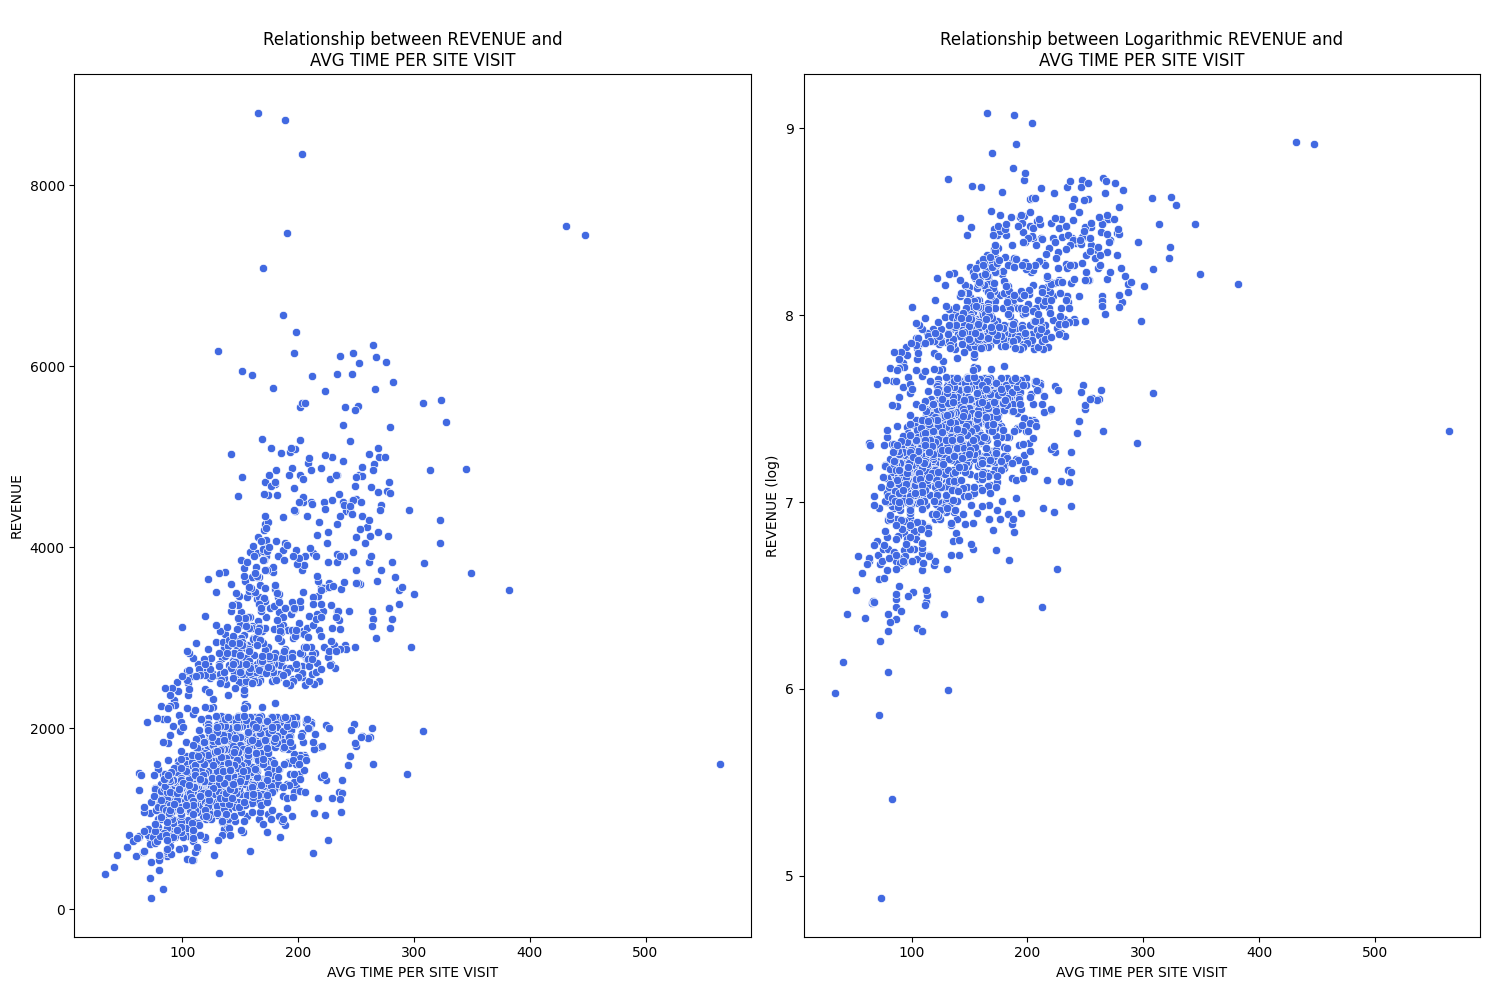

In [58]:
## Scatterplots for the top correlated feature with target

# setting figure size
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(15, 10))


#Plotting scatterplot 1 - AVG_TIME_PER_SITE_VISIT vs REVENUE
sns.scatterplot(x     = chef_df['AVG_TIME_PER_SITE_VISIT'],
                y     = chef_df['REVENUE'],
                color = 'royalblue',
                ax=ax[0])


#setting up labels
ax[0].set_title(label   = """
Relationship between REVENUE and
AVG TIME PER SITE VISIT""")
ax[0].set_xlabel(xlabel = 'AVG TIME PER SITE VISIT')
ax[0].set_ylabel(ylabel = 'REVENUE')

#Plotting scatterplot 2 - AVG_TIME_PER_SITE_VISIT vs log_REVENUE
sns.scatterplot(x     = chef_df['AVG_TIME_PER_SITE_VISIT'],
                y     = chef_df['log_REVENUE'],
                color = 'royalblue',
                ax=ax[1])

#setting up labels
ax[1].set_title(label   = """
Relationship between Logarithmic REVENUE and
AVG TIME PER SITE VISIT""")
ax[1].set_xlabel(xlabel = 'AVG TIME PER SITE VISIT')
ax[1].set_ylabel(ylabel = 'REVENUE (log)')

# cleaning up layout and rendering visual
plt.tight_layout()
plt.show()

Using correlation analysis alone and selecting the feature with the highest correlation to the target variable suggests that increased time spent on the company's site is associated with higher revenue. This relationship indicates that deeper customer engagement may translate into greater purchasing activity. However, correlation analysis is limited in its ability to explain underlying behavioral drivers. The available data did not include average time spent segmented by traffic source, which restricts deeper interpretation. Additional insight could have been gained by disaggregating time spent by platform, such as mobile versus desktop, to better understand how different access channels contribute to engagement and revenue generation.

# Feature Engineering

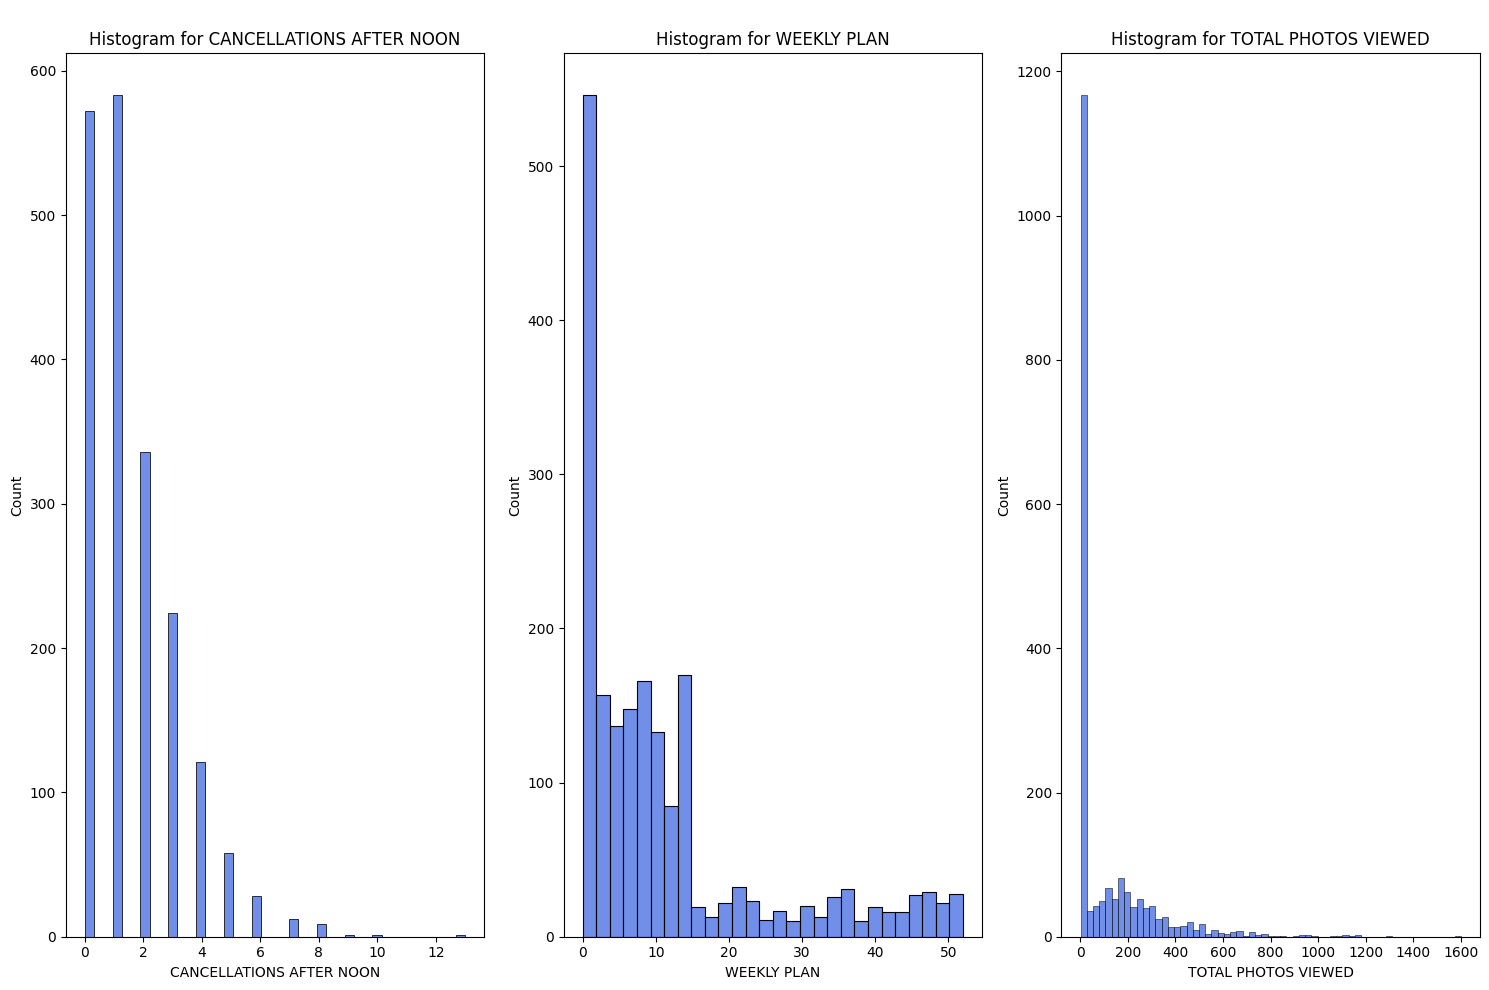

In [59]:
## Exploring existing features to derive new feature engineering

# setting figure size
fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(15, 10))


#Plotting scatterplot 1
sns.histplot(x     = chef_df['CANCELLATIONS_AFTER_NOON'],
                color = 'royalblue',
                ax=ax[0])


#setting up labels
ax[0].set_title(label   = """
Histogram for CANCELLATIONS AFTER NOON""")
ax[0].set_xlabel(xlabel = 'CANCELLATIONS AFTER NOON')
ax[0].set_ylabel(ylabel = 'Count')

#Plotting scatterplot 2
sns.histplot(x     = chef_df['WEEKLY_PLAN'],
                color = 'royalblue',
                ax=ax[1])

#setting up labels
ax[1].set_title(label   = """
Histogram for WEEKLY PLAN""")
ax[1].set_xlabel(xlabel = 'WEEKLY PLAN')
ax[1].set_ylabel(ylabel = 'Count')

#Plotting scatterplot 3
sns.histplot(x     = chef_df['TOTAL_PHOTOS_VIEWED'],
                color = 'royalblue',
                ax=ax[2])

#setting up labels
ax[2].set_title(label   = """
Histogram for TOTAL PHOTOS VIEWED""")
ax[2].set_xlabel(xlabel = 'TOTAL PHOTOS VIEWED')
ax[2].set_ylabel(ylabel = 'Count')

# cleaning up layout and rendering visual
plt.tight_layout()
plt.show()

The first plot indicates that the majority of customers cancelled their orders fewer than four times, while only a small proportion cancelled more than three times. This suggests an opportunity to engineer a binary feature indicating whether a customer cancelled fewer than four times. The second plot display zero-inflated distribution for the weekly plan feature. This pattern indicate further opportunity for feature engineering by creating binary indicator that capture whether a customer had an active weekly plan. The third plot shows that more customers clicked photos fewer than 20 times which created a spike for those customers and a new binary feature can be implemented from this.

In [60]:
# Addressing trailing spaces first
chef_df = chef_df.rename(columns={'LATE_DELIVERIES ': 'LATE_DELIVERIES'})

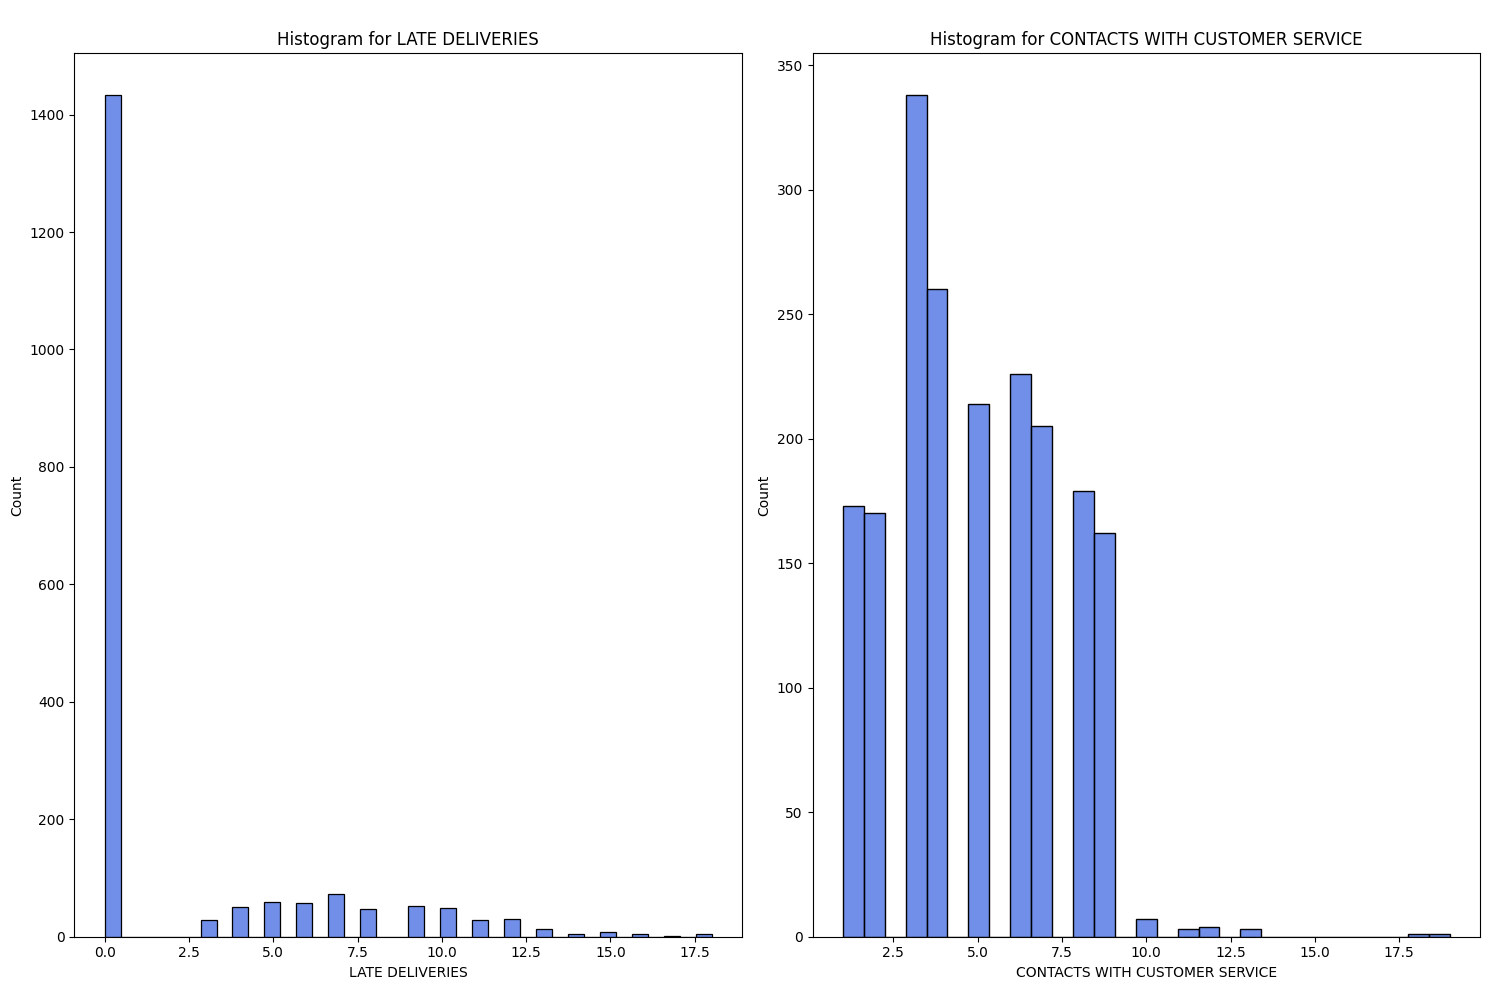

In [61]:
## Exploring existing features to derive new feature engineering

# setting figure size
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(15, 10))


#Plotting scatterplot 1
sns.histplot(x     = chef_df['LATE_DELIVERIES'],
                color = 'royalblue',
                ax=ax[0])


#setting up labels
ax[0].set_title(label   = """
Histogram for LATE DELIVERIES""")
ax[0].set_xlabel(xlabel = 'LATE DELIVERIES')
ax[0].set_ylabel(ylabel = 'Count')

#Plotting scatterplot 2
sns.histplot(x     = chef_df['CONTACTS_W_CUSTOMER_SERVICE'],
                color = 'royalblue',
                ax=ax[1])

#setting up labels
ax[1].set_title(label   = """
Histogram for CONTACTS WITH CUSTOMER SERVICE""")
ax[1].set_xlabel(xlabel = 'CONTACTS WITH CUSTOMER SERVICE')
ax[1].set_ylabel(ylabel = 'Count')


# cleaning up layout and rendering visual
plt.tight_layout()
plt.show()

The plot on the left shows a zero-inflated distribution for late deliveries, with most customers experiencing no delivery delays. This pattern indicates that the presence of any late delivery, rather than the number of late deliveries, is the most meaningful distinction. As a result, a binary feature was engineered to capture whether a customer experienced at least one late delivery. The plot on the right highlights a highly skewed distribution of customer service contacts, where a small subset of customers contact support far more frequently than others. This observation motivated the creation of a binary feature that differentiates frequent support users from those with minimal or no contact.

In [62]:
# counting the number of records for each boolean side
cancellations   = len(chef_df['CANCELLATIONS_AFTER_NOON'][chef_df['CANCELLATIONS_AFTER_NOON']>3]) # CANCELLATIONS_AFTER_NOON
plan_zeroes     = len(chef_df['WEEKLY_PLAN'][chef_df['WEEKLY_PLAN']==0]) # WEEKLY_PLAN
photos = len(chef_df['TOTAL_PHOTOS_VIEWED'][chef_df['TOTAL_PHOTOS_VIEWED']>20]) # TOTAL_PHOTOS_VIEWED
deliveries_zeroes = len(chef_df['LATE_DELIVERIES'][chef_df['LATE_DELIVERIES']==0]) # LATE_DELIVERIES
frequent_support = len(chef_df['CONTACTS_W_CUSTOMER_SERVICE'][chef_df['CONTACTS_W_CUSTOMER_SERVICE']>5]) # CONTACTS_W_CUSTOMER_SERVICE

# printing a table of the results
print(f"""
                         No\t\tYes
                       -----------------------
Fewer Cancellations    | {cancellations}\t\t{len(chef_df) - cancellations}
Weekly Plan            | {plan_zeroes}\t\t{len(chef_df) - plan_zeroes}
Fewer Photos           | {photos}\t\t{len(chef_df) - photos}
Late deliveries        | {deliveries_zeroes}\t\t{len(chef_df) - deliveries_zeroes}
Fewer Support Contacts | {frequent_support}\t\t{len(chef_df) - frequent_support}
""")


                         No		Yes
                       -----------------------
Fewer Cancellations    | 231		1715
Weekly Plan            | 468		1478
Fewer Photos           | 787		1159
Late deliveries        | 1433		513
Fewer Support Contacts | 791		1155



Based on the results above, since all variables have at least 100 observations in both the 'yes' and 'no' columns, new binary trend-based features will be engineered.

In [63]:
# placeholder variables
chef_df['has_More_Cancellations'] = 0
chef_df['has_Weekly_Plan']     = 0
chef_df['has_Clicked_More_Photos']    = 0
chef_df['has_Late_deliveries']      = 0
chef_df['has_More_Support_Contacts']      = 0


# iterating over each original column to change values in the new feature columns
for index, value in chef_df.iterrows():


    # CANCELLATIONS_AFTER_NOON
    if chef_df.loc[index, "CANCELLATIONS_AFTER_NOON"] > 3:
        chef_df.loc[index, 'has_More_Cancellations'] = 1


    # WEEKLY_PLAN
    if chef_df.loc[index, "WEEKLY_PLAN"] > 0:
        chef_df.loc[index, 'has_Weekly_Plan'] = 1


    # TOTAL_PHOTOS_VIEWED
    if chef_df.loc[index, "TOTAL_PHOTOS_VIEWED"] > 20:
        chef_df.loc[index, 'has_Clicked_More_Photos'] = 1


    # LATE_DELIVERIES
    if chef_df.loc[index, "LATE_DELIVERIES"] > 0:
        chef_df.loc[index, 'has_Late_deliveries'] = 1

    # CONTACTS_W_CUSTOMER_SERVICE
    if chef_df.loc[index, "CONTACTS_W_CUSTOMER_SERVICE"] > 5:
        chef_df.loc[index, 'has_More_Support_Contacts'] = 1

**Engineered Feature: High Cancellations Indicator**

A binary feature was engineered to identify customers with unusually high cancellation behaviour by flagging cases where cancellations exceeded three. This threshold separates occasional schedule changes from repeated cancellation patterns that may reflect poor planning fit, dissatisfaction, or inconsistent usage. Converting the original count into a boolean indicator reduces sensitivity to extreme values and makes the signal easier for models to learn. From a business perspective, frequent cancellations can disrupt forecasting and operations, which is especially costly for a meal service built around convenience and efficient preparation. For busy professionals, repeated cancellations may indicate that the product is not aligning with time constraints or lifestyle routines. This indicator therefore supports both predictive performance and actionable segmentation by isolating a high-friction customer group.
(Engineered feature: has_More_Cancellations; rule: cancellations > 3 -> 1)

**Engineered Feature: Weekly Plan Participation Indicator**

A binary feature was created to capture whether a customer is enrolled in a weekly plan by flagging any non-zero plan status. This transformation reflects the practical difference between customers who commit to recurring ordering versus those who purchase more sporadically. Subscription-like behaviour is often associated with higher retention and more stable revenue, which is strategically important for a convenience-focused meal business. The boolean indicator provides a clean segmentation variable and avoids treating plan enrolment as a linear quantity when the key signal is participation versus non-participation. For busy professionals seeking consistent, home-cooked meals without time-consuming preparation, being on a plan can reflect stronger routine formation. This feature is therefore expected to be predictive of revenue and useful for targeted retention strategies.
(Engineered feature: has_Weekly_Plan; rule: weekly plan > 0 -> 1)

**Engineered Feature: High Photo Engagement Indicator**

A binary feature was engineered to identify customers with high visual engagement by flagging cases where photo views exceeded twenty. This threshold captures customers who meaningfully browse and evaluate meal options rather than those who only glance at the platform. High visual interaction can signal stronger purchase intent, greater curiosity, or more deliberate decision-making, all of which are often linked to higher conversion and order value. Encoding this as a boolean indicator reduces the influence of outliers while preserving the behavioural distinction between low and high engagement groups. For Chef's Compass customers, busy professionals balancing health goals with limited time; high browsing engagement may reflect active meal planning for quick-to-prepare, home-style options. This feature supports both revenue prediction and marketing insight by isolating a segment likely to respond to recommendations and new meal offerings.
(Engineered feature: has_Clicked_More_Photos; rule: photos viewed > 20 -> 1)

**Engineered Feature: Late Delivery Experience Indicator**

A binary feature was engineered to capture whether a customer experienced any late delivery by flagging cases where late deliveries were greater than zero. This approach is well-suited to zero-inflated delivery data, where the primary distinction is between “never late” and “late at least once.” The boolean encoding prevents a small number of extreme cases from dominating the learning signal while still capturing operational reliability. Late deliveries represent service friction that can reduce satisfaction, weaken trust, and lower repeat purchasing; especially for time-constrained customers. For busy professionals depending on quick meal preparation, delivery reliability is central to the value proposition of convenience. This feature therefore provides a direct and actionable signal of operational experience that may influence revenue outcomes.
(Engineered feature: has_Late_deliveries; rule: late deliveries > 0 -> 1)

**Engineered Feature: High Customer Support Contact Indicator**

A binary feature was engineered to distinguish frequent customer support users by flagging cases where support contacts exceeded five. This threshold separates routine or occasional support needs from repeated interactions that may reflect friction, confusion, service problems, or higher dependency. Transforming the original count into a boolean indicator improves robustness and highlights the behavioural segment most likely to be affected by service issues. Frequent support contact can also correlate with dissatisfaction or operational disruptions, which may negatively affect retention and spending. In a meal service designed for busy professionals, repeated support reliance undermines the “simple and time saving” promise and may signal churn risk. This feature supports both predictive modelling and operational insight by identifying customers who may benefit from process improvements or proactive support.
(Engineered feature: has_More_Support_Contacts; rule: support contacts > 5 -> 1)


In [64]:
# checking results
chef_df[  ['has_More_Cancellations', 'has_Weekly_Plan', 'has_Clicked_More_Photos',\
           'has_Late_deliveries', 'has_More_Support_Contacts']  ].head(n = 5)

,has_More_Cancellations,has_Weekly_Plan,has_Clicked_More_Photos,has_Late_deliveries,has_More_Support_Contacts
0,1,0,1,0,0
1,0,0,1,0,0
2,0,1,1,0,0
3,1,0,1,0,0
4,0,1,1,0,0


In [65]:
# developing a small correlation matrix
new_corr = chef_df.corr(method = 'pearson').round(decimals = 2)


# checking the correlations of the newly-created variables with REVENUE
new_corr.loc[ ['has_More_Cancellations', 'has_Weekly_Plan', 'has_Clicked_More_Photos',\
           'has_Late_deliveries', 'has_More_Support_Contacts'],
              ['REVENUE', 'log_REVENUE'] ].sort_values(by = 'REVENUE',
                                                             ascending = False)

,REVENUE,log_REVENUE
has_Clicked_More_Photos,0.37,0.39
has_More_Support_Contacts,0.12,0.14
has_More_Cancellations,0.00,-0.00
has_Late_deliveries,-0.02,-0.03
has_Weekly_Plan,-0.03,-0.03


The newly engineered binary features exhibit measurable associations with the target variable, indicating that they capture relevant aspects of customer behavior. Positive correlations suggest that certain engagement and interaction indicators are linked to higher revenue outcomes, while negative correlations point to behaviors associated with reduced spending or friction. However, because these features are boolean in nature, traditional Pearson correlation coefficients provide only limited insight into the true strength of their relationships with revenue. Correlation assumes linear and continuous relationships, which may underrepresent the impact of binary indicators on purchasing behavior. As a result, low or near-zero correlation values do not necessarily imply a lack of predictive usefulness. These engineered features are better evaluated through their contribution to model performance, particularly in nonlinear and tree-based models that can naturally handle categorical splits. Their retention is therefore justified based on observed improvements in predictive accuracy rather than correlation magnitude alone.

# Candidate Model Development

## Feature-target Separation

In [66]:
## feature-target separation ##

# preparing x-data

# all x-features including transformed and newly engineered features
x_all = chef_df.drop([ 'REVENUE', 'log_REVENUE' ], axis = 1)

# all x-features excluding transformed and newly engineered features
x_base = x_all.loc[:, : 'CROSS_SELL_SUCCESS']

# all x-features including transformed feautures
x_base_log = x_all.loc[:, : 'log_TOTAL_PHOTOS_VIEWED']

# all x-features from stepwise selection with original_y used as target
x_all_step = x_all.loc[:, ['AVG_TIME_PER_SITE_VISIT', 'log_TOTAL_MEALS_ORDERED', 'UNIQUE_MEALS_PURCH',
                           'CONTACTS_W_CUSTOMER_SERVICE', 'AVG_MEAN_RATING', 'TOTAL_PHOTOS_VIEWED',
                           'has_More_Support_Contacts', 'LARGEST_ORDER_SIZE'] ]

# all x-features from stepwise selection with log_y used as target
x_step_log_y = x_all.loc[:, ['log_TOTAL_MEALS_ORDERED', 'log_AVG_TIME_PER_SITE_VISIT', 'AVG_MEAN_RATING',
                            'CONTACTS_W_CUSTOMER_SERVICE', 'log_TOTAL_PHOTOS_VIEWED', 'LARGEST_ORDER_SIZE',
                            'UNIQUE_MEALS_PURCH', 'has_More_Support_Contacts', 'TOTAL_MEALS_ORDERED',
                            'AVG_TIME_PER_SITE_VISIT', 'log_AVG_PREP_VID_TIME']]

# Important features from tree based algorithms
x_tree_all = x_all.loc[:, ['TOTAL_MEALS_ORDERED', 'UNIQUE_MEALS_PURCH', 'CONTACTS_W_CUSTOMER_SERVICE', 'PRODUCT_CATEGORIES_VIEWED',
                           'AVG_TIME_PER_SITE_VISIT', 'CANCELLATIONS_AFTER_NOON', 'PC_LOGINS', 'MOBILE_LOGINS', 'WEEKLY_PLAN',
                           'AVG_PREP_VID_TIME', 'LARGEST_ORDER_SIZE', 'AVG_MEAN_RATING', 'TOTAL_PHOTOS_VIEWED', 'log_TOTAL_MEALS_ORDERED',
                           'log_AVG_TIME_PER_SITE_VISIT', 'log_CANCELLATIONS_AFTER_NOON', 'log_WEEKLY_PLAN', 'log_AVG_PREP_VID_TIME',
                           'log_TOTAL_PHOTOS_VIEWED']]


# preparing y-data
original_y = chef_df[ 'REVENUE' ]
log_y      = chef_df[ 'log_REVENUE' ]

In [67]:
# creating placeholder DataFrame for results
results = pd.DataFrame()

## Standardization

In [68]:
# INSTANTIATING a StandardScaler() object
scaler = StandardScaler()


# FITTING and TRANSFORMING
x_scaled = scaler.fit_transform(x_all)


# converting scaled data into a DataFrame
x_scaled_df = pd.DataFrame(x_scaled)


# labeling columns
x_scaled_df.columns = x_all.columns


# checking the results
x_scaled_df.describe(include = 'number').round(decimals = 2)

,TOTAL_MEALS_ORDERED,UNIQUE_MEALS_PURCH,CONTACTS_W_CUSTOMER_SERVICE,PRODUCT_CATEGORIES_VIEWED,AVG_TIME_PER_SITE_VISIT,CANCELLATIONS_AFTER_NOON,PC_LOGINS,MOBILE_LOGINS,WEEKLY_PLAN,LATE_DELIVERIES,AVG_PREP_VID_TIME,LARGEST_ORDER_SIZE,AVG_MEAN_RATING,TOTAL_PHOTOS_VIEWED,CROSS_SELL_SUCCESS,log_TOTAL_MEALS_ORDERED,log_AVG_TIME_PER_SITE_VISIT,log_CANCELLATIONS_AFTER_NOON,log_WEEKLY_PLAN,log_AVG_PREP_VID_TIME,log_TOTAL_PHOTOS_VIEWED,has_More_Cancellations,has_Weekly_Plan,has_Clicked_More_Photos,has_Late_deliveries,has_More_Support_Contacts
count,1946.00,1946.00,1946.00,1946.00,1946.00,1946.00,1946.00,1946.00,1946.00,1946.00,1946.00,1946.00,1946.00,1946.00,1946.00,1946.00,1946.00,1946.00,1946.00,1946.00,1946.00,1946.00,1946.00,1946.00,1946.00,1946.00
mean,0.00,0.00,-0.00,-0.00,0.00,0.00,-0.00,-0.00,0.00,0.00,-0.00,0.00,0.00,0.00,-0.00,0.00,0.00,-0.00,0.00,0.00,-0.00,0.00,0.00,-0.00,0.00,0.00
std,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00
min,-1.15,-2.62,-1.56,-1.44,-2.37,-0.98,-2.61,-2.80,-0.83,-0.54,-1.43,-2.22,-3.65,-0.63,-1.45,-2.26,-4.51,-1.28,-1.44,-4.17,-1.88,-0.37,-1.78,-0.82,-0.60,-0.83
25%,-0.64,-0.87,-0.76,-0.78,-0.73,-0.98,-0.89,-0.90,-0.76,-0.54,-0.44,-0.93,-0.65,-0.58,-1.45,-0.56,-0.70,-1.28,-0.89,-0.41,-0.77,-0.37,0.56,-0.82,-0.60,-0.83
50%,-0.26,0.01,0.04,-0.13,-0.10,-0.35,0.83,-0.90,-0.32,-0.54,-0.09,-0.28,-0.22,-0.54,0.69,0.03,0.05,-0.12,0.19,0.13,-0.45,-0.37,0.56,-0.82,-0.60,-0.83
75%,0.37,0.45,0.84,0.86,0.47,0.27,0.83,0.99,0.12,0.25,0.28,0.36,0.64,0.34,0.69,0.67,0.61,0.56,0.63,0.57,1.02,-0.37,0.56,1.21,1.67,1.21
max,7.57,4.83,5.63,1.52,8.37,7.10,2.56,2.89,3.00,4.21,24.81,4.24,2.35,8.40,0.69,2.98,4.30,3.13,1.67,5.89,2.45,2.72,0.56,1.21,1.67,1.21


## Model 1 - OLS Linear Regression

In [69]:
## baseline model

## stepwise model using REVENUE ##
sp_model = quick_lm(x_data        = x_all,
                    y_data        = log_y,
                    threshold_in  = 0.01,
                    threshold_out = 0.05,
                    test_size     = 0.25)

Add log_TOTAL_MEALS_ORDERED        with p-value 0.000000
Add log_AVG_TIME_PER_SITE_VISIT    with p-value 0.000000
Add AVG_MEAN_RATING                with p-value 0.000000
Add CONTACTS_W_CUSTOMER_SERVICE    with p-value 0.000000
Add log_TOTAL_PHOTOS_VIEWED        with p-value 0.000000
Add LARGEST_ORDER_SIZE             with p-value 0.000000
Add UNIQUE_MEALS_PURCH             with p-value 0.000000
Add has_More_Support_Contacts      with p-value 0.000000
Add TOTAL_MEALS_ORDERED            with p-value 0.000006
Add AVG_TIME_PER_SITE_VISIT        with p-value 0.004553
Add log_AVG_PREP_VID_TIME          with p-value 0.006420

Iterations: 11 | Features: 11 | Train-Test Gap: 0.0187 | PASS


A stepwise linear regression procedure was used as the baseline model to assess feature feasibility and statistical relevance. The model evaluated predictors using p-value thresholds and incorporated a train-test split to ensure generalization. Features retained by the stepwise process demonstrated statistical significance and stable performance, supporting their suitability for downstream modeling. This baseline linear framework served as the foundation for feature selection prior to fitting more complex machine learning models.

In [70]:
## OLS model with x features using base model selected features with log y ##

# storing results
results = lr_summary(x = x_step_log_y,
                     y = log_y,
                     model = sklearn.linear_model.LinearRegression(),
                     model_name = 'OLS Model (log y)',
                     results_df = results)


# checking results
results.head(n = 25)

,Model_Name,Model_Class,Model_Type,train_RSQ,test_RSQ,tt_gap,used_tts,Intercept,log_TOTAL_MEALS_ORDERED,log_AVG_TIME_PER_SITE_VISIT,AVG_MEAN_RATING,CONTACTS_W_CUSTOMER_SERVICE,log_TOTAL_PHOTOS_VIEWED,LARGEST_ORDER_SIZE,UNIQUE_MEALS_PURCH,has_More_Support_Contacts,TOTAL_MEALS_ORDERED,AVG_TIME_PER_SITE_VISIT,log_AVG_PREP_VID_TIME
0,OLS Model (log y),sklearn.linear_model._base,LinearRegression,0.70,0.71,0.02,True,3.74,0.41,0.49,-0.13,0.05,0.03,-0.05,0.02,-0.12,-0.00,0.00,-0.05


**X-feature selection strategy:**

For Ordinary Least Squares regression, predictor variables selected through stepwise regression, including transformed and newly engineered features, were used without standardization, as the model's estimation procedure does not require feature scaling.

## Model 2 - Ridge Regression

In [71]:
# instantiating a ridge model
model = sklearn.linear_model.Ridge(alpha        = 3, #Model regulation
                                   random_state = 702)


# analyzing results
results = lr_summary(x          = x_scaled_df,
                     y          = log_y,
                     model      = model,
                     model_name = 'Scaled Ridge Model',
                     results_df = results)


# checking results
results.head(n = 25)

,Model_Name,Model_Class,Model_Type,train_RSQ,test_RSQ,tt_gap,used_tts,Intercept,log_TOTAL_MEALS_ORDERED,log_AVG_TIME_PER_SITE_VISIT,AVG_MEAN_RATING,CONTACTS_W_CUSTOMER_SERVICE,log_TOTAL_PHOTOS_VIEWED,LARGEST_ORDER_SIZE,UNIQUE_MEALS_PURCH,has_More_Support_Contacts,TOTAL_MEALS_ORDERED,AVG_TIME_PER_SITE_VISIT,log_AVG_PREP_VID_TIME,PRODUCT_CATEGORIES_VIEWED,CANCELLATIONS_AFTER_NOON,PC_LOGINS,MOBILE_LOGINS,WEEKLY_PLAN,LATE_DELIVERIES,AVG_PREP_VID_TIME,TOTAL_PHOTOS_VIEWED,CROSS_SELL_SUCCESS,log_CANCELLATIONS_AFTER_NOON,log_WEEKLY_PLAN,has_More_Cancellations,has_Weekly_Plan,has_Clicked_More_Photos,has_Late_deliveries
0,OLS Model (log y),sklearn.linear_model._base,LinearRegression,0.70,0.71,0.02,True,3.74,0.41,0.49,-0.13,0.05,0.03,-0.05,0.02,-0.12,-0.00,0.00,-0.05,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Scaled Ridge Model,sklearn.linear_model._ridge,Ridge,0.70,0.72,0.02,True,7.53,0.29,0.16,-0.08,0.12,0.00,-0.07,0.06,-0.06,-0.08,0.07,-0.03,0.01,-0.02,-0.01,0.01,-0.00,-0.01,0.01,0.02,-0.01,0.02,0.01,0.01,-0.02,0.03,0.01


**X-feature selection strategy:**

For Ridge regression, all predictor variables were standardized, including transformed and newly engineered features, to allow effective L2 regularization and coefficient shrinkage.

## Model 3 - Lasso Regression

In [72]:
# instantiating a Lasso model
model = sklearn.linear_model.Lasso(alpha        = 0.002,
                                   random_state = 702)


# analyzing results
results = lr_summary(x          = x_scaled_df,
                     y          = log_y,
                     model      = model,
                     model_name = 'Scaled Lasso Model',
                     results_df = results)


# checking results
results.head(n = 25)

,Model_Name,Model_Class,Model_Type,train_RSQ,test_RSQ,tt_gap,used_tts,Intercept,log_TOTAL_MEALS_ORDERED,log_AVG_TIME_PER_SITE_VISIT,AVG_MEAN_RATING,CONTACTS_W_CUSTOMER_SERVICE,log_TOTAL_PHOTOS_VIEWED,LARGEST_ORDER_SIZE,UNIQUE_MEALS_PURCH,has_More_Support_Contacts,TOTAL_MEALS_ORDERED,AVG_TIME_PER_SITE_VISIT,log_AVG_PREP_VID_TIME,PRODUCT_CATEGORIES_VIEWED,CANCELLATIONS_AFTER_NOON,PC_LOGINS,MOBILE_LOGINS,WEEKLY_PLAN,LATE_DELIVERIES,AVG_PREP_VID_TIME,TOTAL_PHOTOS_VIEWED,CROSS_SELL_SUCCESS,log_CANCELLATIONS_AFTER_NOON,log_WEEKLY_PLAN,has_More_Cancellations,has_Weekly_Plan,has_Clicked_More_Photos,has_Late_deliveries
0,OLS Model (log y),sklearn.linear_model._base,LinearRegression,0.70,0.71,0.02,True,3.74,0.41,0.49,-0.13,0.05,0.03,-0.05,0.02,-0.12,-0.00,0.00,-0.05,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Scaled Ridge Model,sklearn.linear_model._ridge,Ridge,0.70,0.72,0.02,True,7.53,0.29,0.16,-0.08,0.12,0.00,-0.07,0.06,-0.06,-0.08,0.07,-0.03,0.01,-0.02,-0.01,0.01,-0.00,-0.01,0.01,0.02,-0.01,0.02,0.01,0.01,-0.02,0.03,0.01
2,Scaled Lasso Model,sklearn.linear_model._coordinate_descent,Lasso,0.70,0.72,0.02,True,7.53,0.26,0.16,-0.08,0.11,0.00,-0.07,0.05,-0.04,-0.06,0.06,-0.02,0.01,-0.00,-0.00,0.01,-0.00,-0.00,0.00,0.02,-0.01,0.00,-0.00,-0.00,-0.01,0.04,-0.00


**X-feature selection strategy:**

For Lasso regression, all predictor variables were standardized, including transformed and newly engineered features, to allow effective L1 regularization and coefficient shrinkage.

## Model 4 - Elastic Net Regression

In [73]:
# instantiating a ridge model
model = sklearn.linear_model.SGDRegressor(loss     = 'squared_error',
                                          penalty  = 'elasticnet',
                                          alpha    = 0.0001,
                                          l1_ratio = 0.2,
                                          random_state = 702)


# analyzing results
results = lr_summary(x          = x_scaled_df,
                     y          = log_y,
                     model      = model,
                     model_name = 'Scaled SGD Model',
                     results_df = results)


# checking results
results.head(n = 25)

,Model_Name,Model_Class,Model_Type,train_RSQ,test_RSQ,tt_gap,used_tts,Intercept,log_TOTAL_MEALS_ORDERED,log_AVG_TIME_PER_SITE_VISIT,AVG_MEAN_RATING,CONTACTS_W_CUSTOMER_SERVICE,log_TOTAL_PHOTOS_VIEWED,LARGEST_ORDER_SIZE,UNIQUE_MEALS_PURCH,has_More_Support_Contacts,TOTAL_MEALS_ORDERED,AVG_TIME_PER_SITE_VISIT,log_AVG_PREP_VID_TIME,PRODUCT_CATEGORIES_VIEWED,CANCELLATIONS_AFTER_NOON,PC_LOGINS,MOBILE_LOGINS,WEEKLY_PLAN,LATE_DELIVERIES,AVG_PREP_VID_TIME,TOTAL_PHOTOS_VIEWED,CROSS_SELL_SUCCESS,log_CANCELLATIONS_AFTER_NOON,log_WEEKLY_PLAN,has_More_Cancellations,has_Weekly_Plan,has_Clicked_More_Photos,has_Late_deliveries
0,OLS Model (log y),sklearn.linear_model._base,LinearRegression,0.70,0.71,0.02,True,3.74,0.41,0.49,-0.13,0.05,0.03,-0.05,0.02,-0.12,-0.00,0.00,-0.05,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Scaled Ridge Model,sklearn.linear_model._ridge,Ridge,0.70,0.72,0.02,True,7.53,0.29,0.16,-0.08,0.12,0.00,-0.07,0.06,-0.06,-0.08,0.07,-0.03,0.01,-0.02,-0.01,0.01,-0.00,-0.01,0.01,0.02,-0.01,0.02,0.01,0.01,-0.02,0.03,0.01
2,Scaled Lasso Model,sklearn.linear_model._coordinate_descent,Lasso,0.70,0.72,0.02,True,7.53,0.26,0.16,-0.08,0.11,0.00,-0.07,0.05,-0.04,-0.06,0.06,-0.02,0.01,-0.00,-0.00,0.01,-0.00,-0.00,0.00,0.02,-0.01,0.00,-0.00,-0.00,-0.01,0.04,-0.00
3,Scaled SGD Model,sklearn.linear_model._stochastic_gradient,SGDRegressor,0.69,0.71,0.02,True,7.53,0.22,0.16,-0.09,0.12,0.05,-0.08,0.03,-0.05,-0.02,0.08,-0.03,0.01,0.00,-0.00,0.01,-0.02,-0.00,0.00,-0.00,-0.01,0.01,0.03,0.00,-0.03,0.02,0.00


**X-feature selection strategy:**

For Elastic Net regression, standardized predictors, including transformed and engineered variables, were used to allow fair application of both L1 and L2 regularization penalties.

## Model 5 - K-Nearest Neighbors

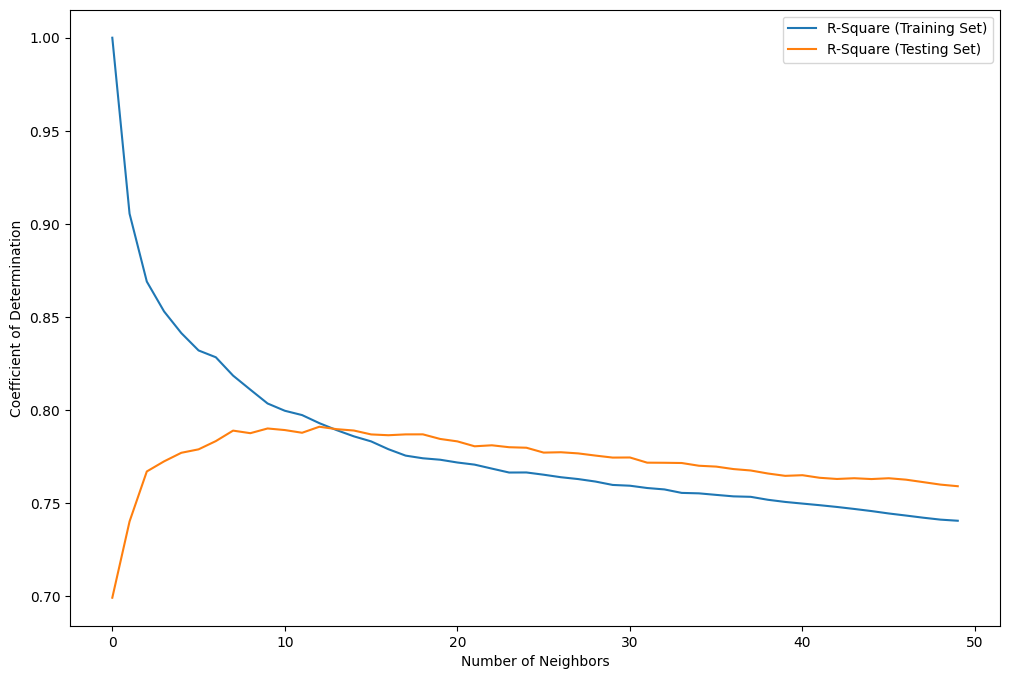


    The optimal number of neighbors is 13.
    Training R-Square: 0.7929
    Testing  R-Square: 0.791
    Train-Test Gap:    0.0019



In [74]:
# applying quick neighbors on standardized data
knn_model = quick_neighbors(x_data        = x_step_log_y,
                            y_data        = log_y,
                            model_type    = KNeighborsRegressor,
                            max_neighbors = 50,
                            standardize   = True,
                            visualize     = True,
                            verbose       = True)

**X-feature selection strategy:**

For the K-Nearest Neighbors model, standardized predictor variables selected through stepwise regression, including transformed and newly engineered features, were used to ensure balanced distance calculations and were found to produce the highest training performance with the lowest train-test variance compared to alternative feature sets.

## Model 6 - Random Forest

In [75]:
########################################
# plot_feature_importances
########################################
def plot_feature_importances(model, x_data, export = False):
    """
    Plots the importance of features from a CART model.

    PARAMETERS
    ----------
    model  : CART model
    x_data : x-feature data
    export : whether or not to export as a .png image, default False
    """

    # declaring the number
    n_features = x_data.shape[1]

    # setting plot window
    fig, ax = plt.subplots(figsize=(12,9))

    plt.barh(range(n_features), model.feature_importances_, align='center')
    plt.yticks(np.arange(n_features), x_data.columns)
    plt.xlabel("Feature importance")
    plt.ylabel("Feature")

    if export == True:
        plt.savefig('Tree_Leaf_50_Feature_Importance.png')

In [76]:
# train-test split
x_train, x_test, y_train, y_test = train_test_split(
            x_all,
            original_y,
            test_size    = 0.25,
            random_state = 702)

In [77]:
# INSTANTIATING a random forest model with default values
model = RandomForestRegressor(n_estimators     = 30,
                              criterion        = 'squared_error',
                              max_features = None,
                              max_depth        = 12,
                              min_samples_leaf = 15,
                              bootstrap        = True,
                              warm_start       = False,
                              random_state     = 702)


# FITTING the training data
model_fit = model.fit(x_train, y_train)


# PREDICTING based on the testing set
model_pred = model.predict(x_test)


# SCORING the results
model_train_score = round(model.score(x_train, y_train), ndigits = 4)
model_test_score  = round(model.score(x_test , y_test) , ndigits = 4)
model_gap         = round(abs(model_train_score - model_test_score), ndigits = 4)


# displaying results
print('Training Score :', model_train_score)
print('Testing Score  :', model_test_score)
print('Train-Test Gap :', model_gap)

Training Score : 0.7877
Testing Score  : 0.7714
Train-Test Gap : 0.0163


**X-feature selection strategy:**

For the RandomForestRegressor, the full set of non-standardized predictor variables, including transformed and engineered features, was retained, as tree-based models are insensitive to feature scaling and capable of capturing nonlinear relationships and interactions.

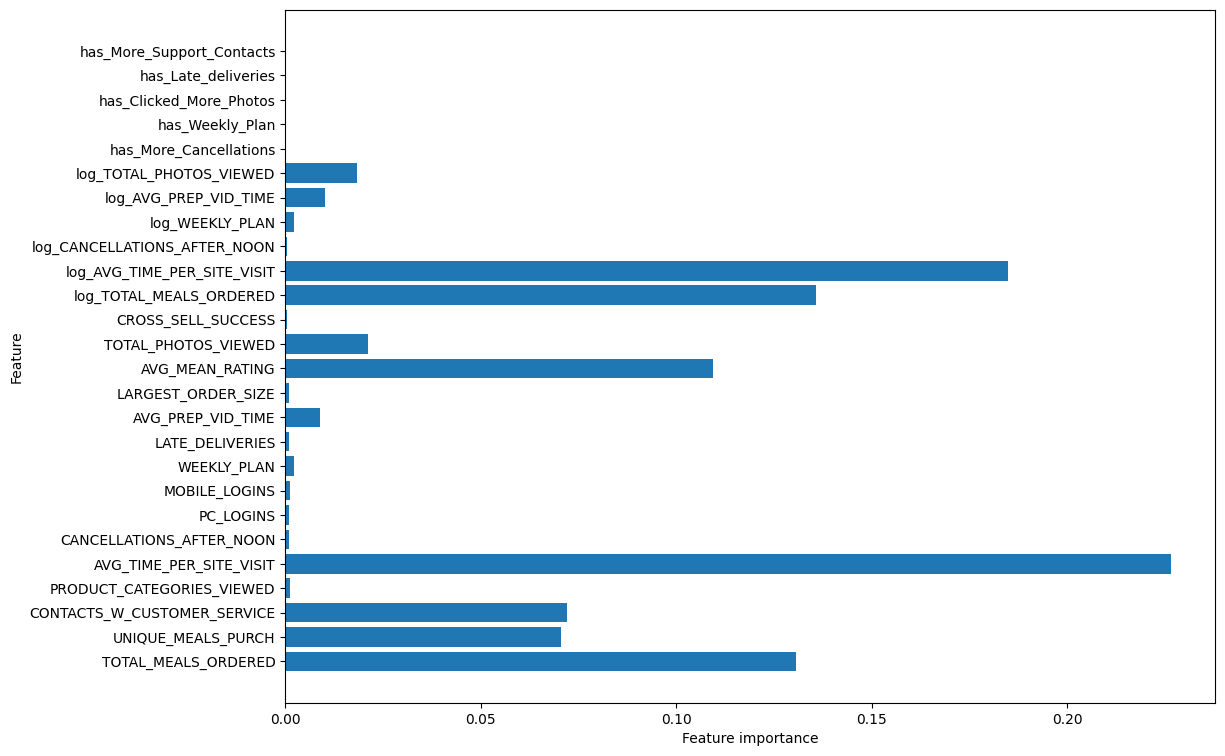

In [78]:
# plotting feature importance
plot_feature_importances(model,
                         x_data = x_all,
                         export = False )

The feature selection results from the Random Forest model highlight behavioral patterns that are strongly associated with increased revenue for Chef's Compass. Features related to order frequency, meal variety, and overall purchasing intensity suggest that customers who consistently order and explore different meal options contribute more to long-term revenue. Engagement indicators such as time spent browsing, interaction with visual and instructional content, and recipe preparation guidance imply that deeper platform interaction translates into higher purchasing commitment. This aligns well with the preferences of busy professionals who value convenience but still seek healthy, home-cooked meals that are quick to prepare. Customer satisfaction signals further indicate that positive meal experiences reinforce repeat purchasing behavior. Additionally, features capturing service interactions and cancellation behavior provide insight into operational friction, helping distinguish high-value customers from those at risk of disengagement. The presence of both absolute and nonlinear engagement effects suggests that revenue growth is driven not only by higher activity levels but also by diminishing returns as customers mature. Overall, the Random Forest feature importance supports a feature selection strategy grounded in customer behavior, engagement quality, and convenience-driven consumption patterns central to the Chef's Compass business model.

## Model 7 - Gradient Boosting Machine

In [79]:
# preparing x-features (standardized)
x_data = x_scaled_df


# preparing y-feature
y_data = original_y


# train-test split
x_train, x_test, y_train, y_test = train_test_split(
            x_data,
            y_data,
            test_size    = 0.25,
            random_state = 702)

In [80]:
# INSTANTIATING the model object
model = GradientBoostingRegressor(loss             = 'squared_error',
                                  learning_rate    = 0.03,   #how much each tree corrects the previous mistakes
                                  n_estimators     = 70,
                                  criterion        = 'friedman_mse',
                                  min_samples_leaf = 15,
                                  max_depth        = 6,
                                  warm_start       = False,
                                  subsample        = 0.5,  #how much data each tree sees
                                  max_features     = None,
                                  random_state     = 702)


# FITTING the training data
model_fit = model.fit(x_train, y_train)


# PREDICTING based on the testing set
model_pred = model.predict(x_test)


# SCORING the results
model_train_score = round(model.score(x_train, y_train), ndigits = 4)
model_test_score  = round(model.score(x_test , y_test) , ndigits = 4)
model_gap         = round(abs(model_train_score - model_test_score), ndigits = 4)


# displaying results
print('Training Score :', model_train_score)
print('Testing Score  :', model_test_score)
print('Train-Test Gap :', model_gap)

Training Score : 0.8133
Testing Score  : 0.7816
Train-Test Gap : 0.0317


**X-feature selection strategy:**

For the GradientBoostingRegressor, the full set of standardized features, including transformed and engineered variables, was used to maximize the model's capacity to learn complex nonlinear patterns.

# Final Model

## Model - KNN

In [81]:
# INSTANTIATING a StandardScaler() object
scaler = StandardScaler()


# FITTING and TRANSFORMING
x_scaled = scaler.fit_transform(x_step_log_y)


# converting scaled data into a DataFrame
x_scaled_df = pd.DataFrame(x_scaled)


# labeling columns
x_scaled_df.columns = x_step_log_y.columns


# checking the results
x_scaled_df.describe(include = 'number').round(decimals = 2)

,log_TOTAL_MEALS_ORDERED,log_AVG_TIME_PER_SITE_VISIT,AVG_MEAN_RATING,CONTACTS_W_CUSTOMER_SERVICE,log_TOTAL_PHOTOS_VIEWED,LARGEST_ORDER_SIZE,UNIQUE_MEALS_PURCH,has_More_Support_Contacts,TOTAL_MEALS_ORDERED,AVG_TIME_PER_SITE_VISIT,log_AVG_PREP_VID_TIME
count,1946.00,1946.00,1946.00,1946.00,1946.00,1946.00,1946.00,1946.00,1946.00,1946.00,1946.00
mean,0.00,0.00,0.00,-0.00,-0.00,0.00,0.00,0.00,0.00,0.00,0.00
std,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00
min,-2.26,-4.51,-3.65,-1.56,-1.88,-2.22,-2.62,-0.83,-1.15,-2.37,-4.17
25%,-0.56,-0.70,-0.65,-0.76,-0.77,-0.93,-0.87,-0.83,-0.64,-0.73,-0.41
50%,0.03,0.05,-0.22,0.04,-0.45,-0.28,0.01,-0.83,-0.26,-0.10,0.13
75%,0.67,0.61,0.64,0.84,1.02,0.36,0.45,1.21,0.37,0.47,0.57
max,2.98,4.30,2.35,5.63,2.45,4.24,4.83,1.21,7.57,8.37,5.89


In [82]:
# selecting feature sets
x_data = x_scaled_df   #scaled features from linear stepwise selection
y_data = log_y


# this is the exact code we were using before
x_train, x_test, y_train, y_test = train_test_split(
            x_data,
            y_data,
            test_size    = 0.25,
            random_state = 702 )


In [83]:
# INSTANTIATING a KNN model object
knn_reg = KNeighborsRegressor(algorithm = 'auto',
                              n_neighbors = 13
                              )


# FITTING to the training data
knn_fit = knn_reg.fit(x_train, y_train)


# PREDICTING on new data
knn_reg_pred = knn_fit.predict(x_test)


# SCORING the results
knn_reg_score_train = round(knn_reg.score(x_train, y_train), ndigits = 4)
knn_reg_score_test  = round(knn_reg.score(x_test, y_test), ndigits = 4)
knn_reg_test_gap = round(abs(knn_reg_score_train - knn_reg_score_test), ndigits = 4)


# checking results
print(f"""
K-Nearest Neighbors
-------------------
Training Score: {knn_reg_score_train}
Testing Score : {knn_reg_score_test}
Train-Test Gap: {knn_reg_test_gap}
""")


K-Nearest Neighbors
-------------------
Training Score: 0.7929
Testing Score : 0.791
Train-Test Gap: 0.0019



### Model Interpretation

Based on the candidate model evaluation, the K-Nearest Neighbors regressor with n_neighbors = 13 was selected as the final model. Although Gradient Boosting achieved a higher training R squared, KNN produced the highest testing R squared (0.791) and the smallest train-test gap (0.0019), indicating superior generalization to unseen data. This suggests that the KNN model achieves a more favorable bias-variance balance for the Chef's Compass dataset and is less prone to overfitting compared to the tree-based ensemble methods. Interpretability is introduced through the modeling pipeline, as input features were selected using a statistically guided stepwise regression procedure and standardized prior to modeling. As a result, predictions are driven by similarity across a reduced and meaningful set of explanatory variables rather than noise from irrelevant features. Each prediction reflects outcomes observed among the most similar historical observations in the feature space, providing localized interpretability. While KNN does not yield global effect sizes or feature coefficients, its reliance on well-selected and scaled predictors ensures that model behavior remains transparent and methodologically sound. Overall, the selected KNN model balances predictive performance, stability, and interpretability in a manner appropriate for the objectives of the Chef's Compass analysis.

# AI Declaration

> No AI was used.

